In [1]:
# Install required libraries if not installed
# pip install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree


In [2]:
# Load Titanic dataset (train.csv)
df = pd.read_csv("Titanic-Dataset.csv")

In [3]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
# Quick overview
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
524,525,0,3,"Kassem, Mr. Fared",male,NaN,0,0,2700,7.2292,NaN,C
360,361,0,3,"Skoog, Mr. Wilhelm",male,40.0,1,4,347088,27.9000,NaN,S
164,165,0,3,"Panula, Master. Eino Viljami",male,1.0,4,1,3101295,39.6875,NaN,S
812,813,0,2,"Slemen, Mr. Richard James",male,35.0,0,0,28206,10.5000,NaN,S
20,21,0,2,"Fynney, Mr. Joseph J",male,35.0,0,0,239865,26.0000,NaN,S


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
df.isnull().sum() # check missing values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Handle Missing Values using .loc

In [20]:
df["Age"].isnull().sum()

np.int64(177)

In [18]:
df.loc[df["Age"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


In [21]:
df['Age'].median()

np.float64(28.0)

In [22]:
# Fill missing Age with median using loc
df.loc[df['Age'].isnull(), 'Age']=28.0

In [23]:
# or you can direclty used
# Fill missing Age with median using loc
df.loc[df['Age'].isnull(), 'Age'] = df['Age'].median()

In [24]:
# check age columns only
df["Age"].isnull().sum()

np.int64(0)

In [25]:
# or you can even use 
df.loc[df["Age"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [27]:
# for test whole 
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
df.isnull().sum()

In [28]:
df.loc[:,"Embarked"].mode()

0    S
Name: Embarked, dtype: object

In [30]:
df["Embarked"].mode()

0    S
Name: Embarked, dtype: object

In [29]:
# Fill missing Embarked with mode using loc
df.loc[df['Embarked'].isnull(), 'Embarked']="s"

In [31]:
# Fill missing Embarked with mode using loc
df.loc[df['Embarked'].isnull(), 'Embarked'] = df['Embarked'].mode()[0]

In [32]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [33]:
df.drop(columns="Cabin",inplace=True)

In [34]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [35]:
# Family size: SibSp + Parch + 1
df.loc[:, 'FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [ ]:
df.loc[:, 'IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1
# IsAlone: 1 if single, 0 if with family


In [36]:
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1


In [37]:
# Extract Title from Name
df.loc[:, 'Title'] = df['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())
df["Title"]

0        Mr
1       Mrs
2      Miss
3       Mrs
4        Mr
       ... 
886     Rev
887    Miss
888    Miss
889      Mr
890      Mr
Name: Title, Length: 891, dtype: object

In [38]:
# Simplify rare titles
rare_titles = ['Lady', 'Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona']


In [39]:
df["Title"].mode()

0    Mr
Name: Title, dtype: object

In [40]:
df.loc[df['Title'].isin(rare_titles), 'Title'] = 'Rare'
df.loc[df['Title'].isin(['Mlle', 'Ms']), 'Title'] = 'Miss'
df.loc[df['Title'] == 'Mme', 'Title'] = 'Mrs'

In [41]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,1,Rare
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,1,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,4,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,1,Mr


In [42]:
# One-hot encoding for categorical features
df = pd.get_dummies(df, columns=['Sex','Embarked','Title'], drop_first=True)


In [43]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S,Embarked_s,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Title_the Countess
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,2,True,False,True,False,False,True,False,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,2,False,False,False,False,False,False,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,1,False,False,True,False,True,False,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,2,False,False,True,False,False,False,True,False,False
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,1,True,False,True,False,False,True,False,False,False


In [44]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S,Embarked_s,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Title_the Countess
57,58,0,3,"Novel, Mr. Mansouer",28.5,0,0,2697,7.2292,1,True,False,False,False,False,True,False,False,False
698,699,0,1,"Thayer, Mr. John Borland",49.0,1,1,17421,110.8833,3,True,False,False,False,False,True,False,False,False
510,511,1,3,"Daly, Mr. Eugene Patrick",29.0,0,0,382651,7.7500,1,True,True,False,False,False,True,False,False,False
121,122,0,3,"Moore, Mr. Leonard Charles",28.0,0,0,A4. 54510,8.0500,1,True,False,True,False,False,True,False,False,False
237,238,1,2,"Collyer, Miss. Marjorie ""Lottie""",8.0,0,2,C.A. 31921,26.2500,3,False,False,True,False,True,False,False,False,False


In [45]:
df.isnull().sum()

PassengerId           0
Survived              0
Pclass                0
Name                  0
Age                   0
SibSp                 0
Parch                 0
Ticket                0
Fare                  0
FamilySize            0
Sex_male              0
Embarked_Q            0
Embarked_S            0
Embarked_s            0
Title_Miss            0
Title_Mr              0
Title_Mrs             0
Title_Rare            0
Title_the Countess    0
dtype: int64

In [46]:
# Features and target
X = df.drop(['PassengerId','Name','Ticket','Survived'], axis=1)
y = df['Survived']

In [47]:
X

,Pclass,Age,SibSp,Parch,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S,Embarked_s,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Title_the Countess
0,3,22.0,1,0,7.2500,2,True,False,True,False,False,True,False,False,False
1,1,38.0,1,0,71.2833,2,False,False,False,False,False,False,True,False,False
2,3,26.0,0,0,7.9250,1,False,False,True,False,True,False,False,False,False
3,1,35.0,1,0,53.1000,2,False,False,True,False,False,False,True,False,False
4,3,35.0,0,0,8.0500,1,True,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,27.0,0,0,13.0000,1,True,False,True,False,False,False,False,True,False
887,1,19.0,0,0,30.0000,1,False,False,True,False,True,False,False,False,False
888,3,28.0,1,2,23.4500,4,False,False,True,False,True,False,False,False,False
889,1,26.0,0,0,30.0000,1,True,False,False,False,False,True,False,False,False


In [48]:
# Split dataset 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [50]:
# Initialize Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

# Train
dt_model.fit(X_train, y_train)

# Predict on test set
y_pred = dt_model.predict(X_test)


In [51]:
y_pred 

array([0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1])

In [52]:
# Accuracy and classification report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7932960893854749
              precision    recall  f1-score   support

           0       0.83      0.81      0.82       105
           1       0.74      0.77      0.75        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179



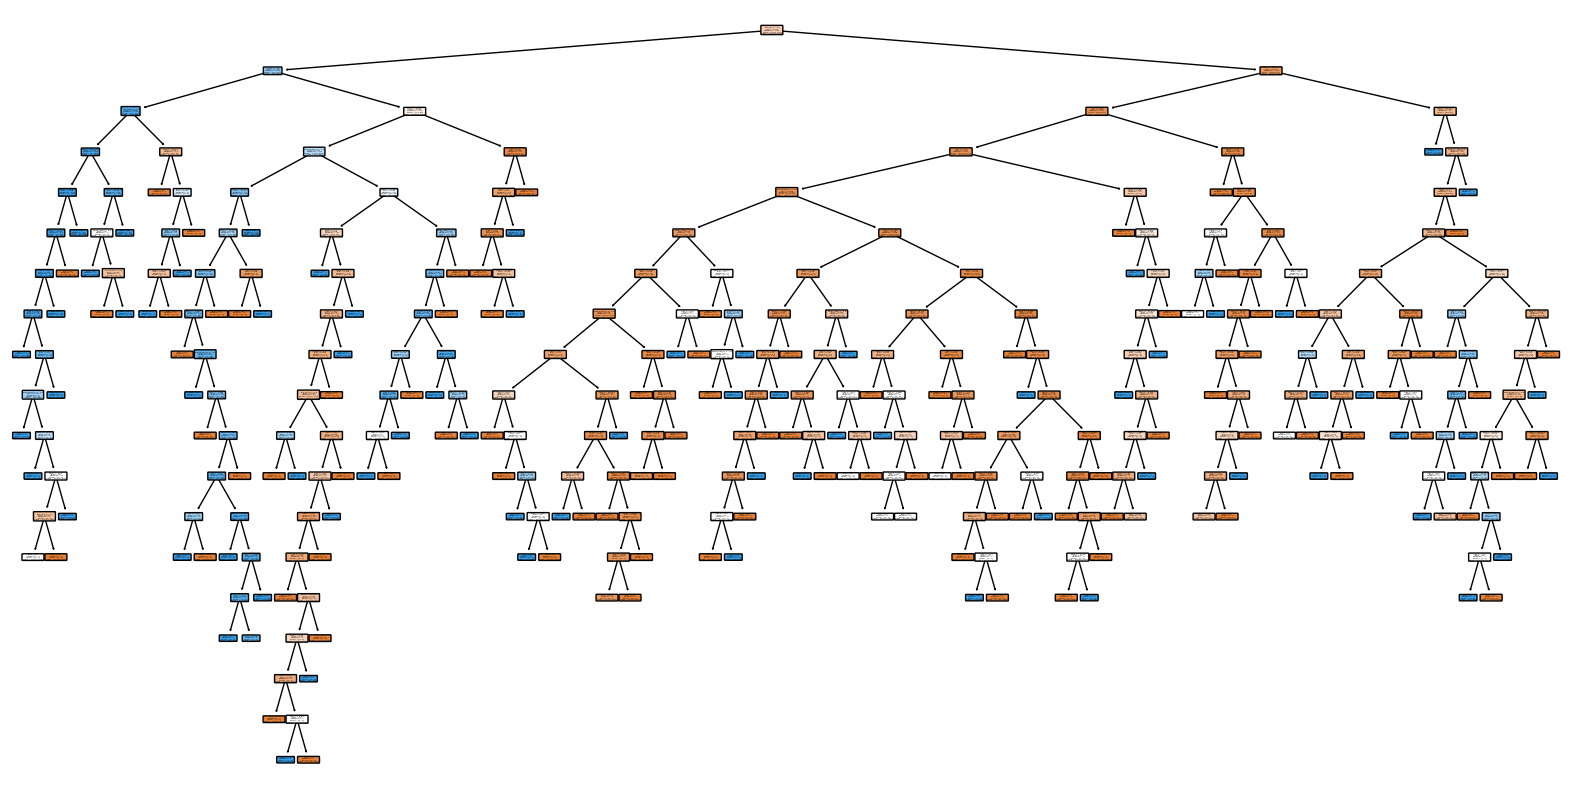

In [53]:
plt.figure(figsize=(20,10))
tree.plot_tree(dt_model, feature_names=X.columns, class_names=['Not Survived','Survived'], filled=True, rounded=True)
plt.show()


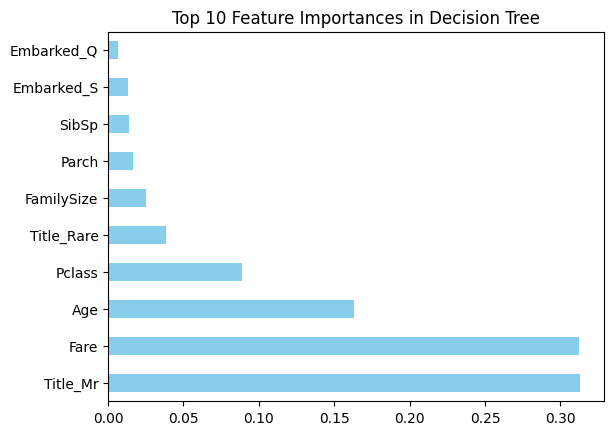

In [54]:
feat_importances = pd.Series(dt_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title("Top 10 Feature Importances in Decision Tree")
plt.show()


In [55]:
X_test

,Pclass,Age,SibSp,Parch,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S,Embarked_s,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Title_the Countess
709,3,28.0,1,1,15.2458,3,True,False,False,False,False,False,False,False,False
439,2,31.0,0,0,10.5000,1,True,False,True,False,False,True,False,False,False
840,3,20.0,0,0,7.9250,1,True,False,True,False,False,True,False,False,False
720,2,6.0,0,1,33.0000,2,False,False,True,False,True,False,False,False,False
39,3,14.0,1,0,11.2417,2,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,3,17.0,0,0,7.1250,1,True,False,True,False,False,True,False,False,False
773,3,28.0,0,0,7.2250,1,True,False,False,False,False,True,False,False,False
25,3,38.0,1,5,31.3875,7,False,False,True,False,False,False,True,False,False
84,2,17.0,0,0,10.5000,1,False,False,True,False,True,False,False,False,False


In [56]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))


Random Forest Accuracy: 0.8379888268156425


In [ ]:
X_test

In [57]:
import joblib

# Save the trained Decision Tree model
joblib.dump(dt_model, "titanic_decision_tree.pkl")

# Later, you can load it like this:
# loaded_model = joblib.load("titanic_decision_tree.pkl")


['titanic_decision_tree.pkl']

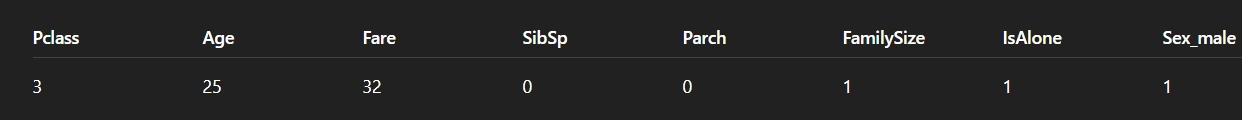

In [58]:
from PIL import Image
from IPython.display import display

img = Image.open("img1.jpg")
display(img)

In [ ]:
from PIL import Image
from IPython.display import display

img = Image.open("img.jpg")
display(img)